<a href="https://colab.research.google.com/github/hsb-ctrl-zy/multi-team1-project/blob/main/%EC%BD%94%EB%9E%A9/%EB%B3%B8%EB%AC%B8_%EA%B8%80%EC%9E%90_%EC%88%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 필요 라이브러리 설치 및 로드

In [1]:
!pip install pymysql

In [2]:
import pymysql

### SQL 연결

In [3]:

#데이터베이스 연결
conn=pymysql.connect(
    host=host_name,
    user=user_name,
    password=password_val,
    database=db_name,
    port=port_num,
    charset='utf8'
)

### MySQL 연결 상태 확인

In [4]:
if conn:
    try:
        # 커서를 생성하여 쿼리 실행 준비
        with conn.cursor() as cursor:
            # 간단한 쿼리로 현재 연결된 데이터베이스 이름을 확인
            cursor.execute("SELECT DATABASE();")
            result = cursor.fetchone()
            if result and result[0]:
                print(f"데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: {result[0]}")
            else:
                print("데이터베이스에 연결되었지만, 현재 데이터베이스 이름을 가져올 수 없습니다.")
    except pymysql.Error as e:
        print(f"데이터베이스 연결 확인 중 오류 발생: {e}")
        print("연결에 문제가 있을 수 있습니다.")
else:
    print("데이터베이스 연결 객체(conn)가 생성되지 않았습니다. 연결이 실패했을 수 있습니다.")

데이터베이스 연결이 성공적으로 확인되었습니다. 현재 데이터베이스: geo_db


### `text_contents` 글자 수 분석

In [5]:
import pandas as pd

try:
    with conn.cursor() as cursor:
        # raw_data_table에서 text_contents 컬럼만 가져오는 쿼리
        sql_query = "SELECT text_contents FROM raw_data_table;"
        cursor.execute(sql_query)

        # 모든 결과 가져오기
        all_contents = cursor.fetchall()

        # 결과를 DataFrame으로 변환
        df_contents = pd.DataFrame(all_contents, columns=['text_contents'])

        print(f"총 {len(df_contents)}개의 텍스트를 가져왔습니다.")

except pymysql.Error as e:
    print(f"데이터베이스 쿼리 실행 중 오류 발생: {e}")
except Exception as e:
    print(f"예상치 못한 오류 발생: {e}")


총 8763개의 텍스트를 가져왔습니다.


In [6]:
# text_contents의 글자 수 계산 (NaN 값은 0으로 처리하거나 제외)
df_contents['text_length'] = df_contents['text_contents'].apply(lambda x: len(str(x)) if x is not None else 0)

# 글자 수에 대한 기술 통계량 출력
print("텍스트 글자 수에 대한 기술 통계량:")
display(df_contents['text_length'].describe())


텍스트 글자 수에 대한 기술 통계량:


,text_length
count,8763.000000
mean,269.940203
std,582.533216
min,0.000000
25%,0.000000
50%,6.000000
75%,428.000000
max,4238.000000


In [11]:
try:
    with conn.cursor() as cursor:
        # raw_data_table에서 text_contents와 brand_type 컬럼을 가져오는 쿼리
        sql_query_brand = "SELECT text_contents, brand_type FROM raw_data_table;"
        cursor.execute(sql_query_brand)

        # 모든 결과 가져오기
        all_data_with_brand = cursor.fetchall()

        # 결과를 DataFrame으로 변환
        df_with_brand = pd.DataFrame(all_data_with_brand, columns=['text_contents', 'brand_type'])

        print(f"총 {len(df_with_brand)}개의 텍스트와 브랜드 타입 데이터를 가져왔습니다.")

except pymysql.Error as e:
    print(f"데이터베이스 쿼리 실행 중 오류 발생: {e}")
except Exception as e:
    print(f"예상치 못한 오류 발생: {e}")


총 8763개의 텍스트와 브랜드 타입 데이터를 가져왔습니다.


In [12]:
# text_contents의 글자 수 계산 (NaN 값은 0으로 처리하거나 제외)
df_with_brand['text_length'] = df_with_brand['text_contents'].apply(lambda x: len(str(x)) if x is not None else 0)

# brand_type별 평균 글자 수 분석
print("\nBrand Type별 텍스트 글자 수 평균:")
display(df_with_brand.groupby('brand_type')['text_length'].mean().reset_index())



Brand Type별 텍스트 글자 수 평균:


,brand_type,text_length
0,대기업,197.197739
1,소상공인,408.761699


In [ ]:
# 나눔고딕 폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm -rf ~/.cache/matplotlib

In [8]:
### Matplotlib 한글 폰트 설정 (깨짐 방지)

import matplotlib.pyplot as plt
import platform

# 운영체제에 맞는 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("Matplotlib 한글 폰트 설정 완료.")

Matplotlib 한글 폰트 설정 완료.


### 데이터 행 수에 따른 텍스트 글자 수 산점도

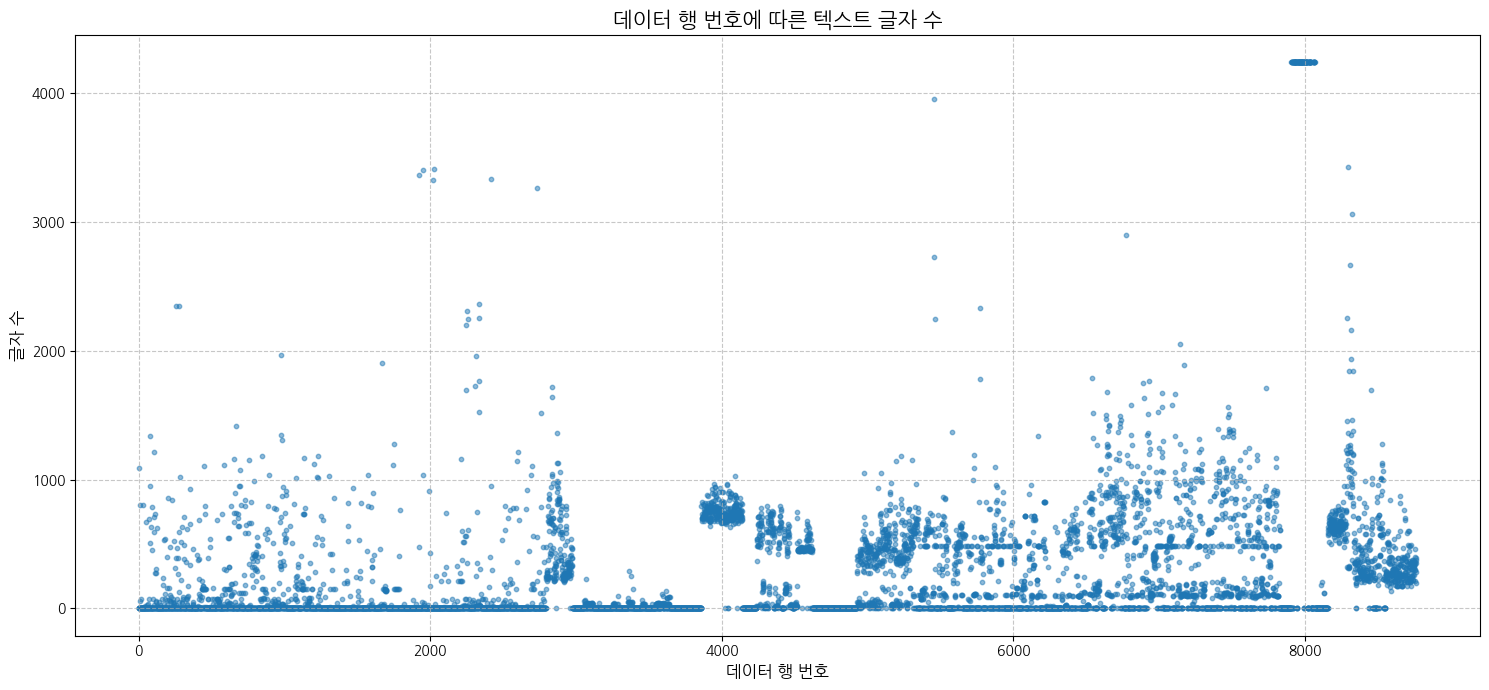

In [9]:
# 데이터 행 수(인덱스)와 글자 수를 이용한 산점도 그래프 시각화
fig = plt.figure(figsize=(15, 7))
plt.scatter(df_contents.index, df_contents['text_length'], alpha=0.5, s=10) # s는 마커 크기

plt.title('데이터 행 번호에 따른 텍스트 글자 수', fontsize=15)
plt.xlabel('데이터 행 번호', fontsize=12)
plt.ylabel('글자 수', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('본문 텍스트 글자 수(scat).png')

plt.show()


### 데이터 행 수에 따른 텍스트 글자 수 히스토그램

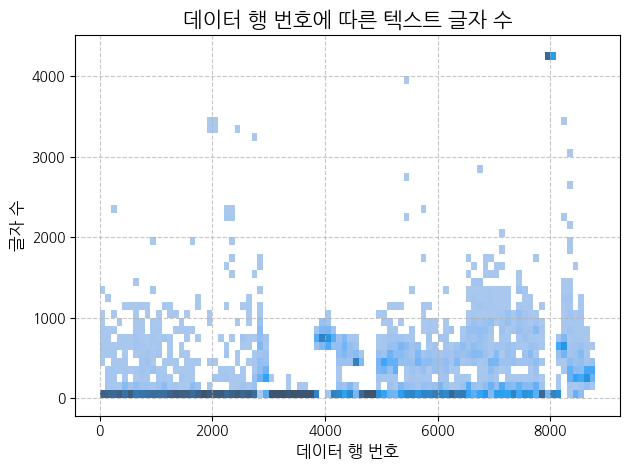

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df_contents, x=df_contents.index,y=df_contents['text_length'], binwidth=100, kde=True)
plt.title('데이터 행 번호에 따른 텍스트 글자 수', fontsize=15)
plt.xlabel('데이터 행 번호', fontsize=12)
plt.ylabel('글자 수', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('본문 텍스트 글자 수(hist).png')

plt.show()

### 대기업 vs 소상공인 텍스트 글자 수 비교

/tmp/ipykernel_1029/2477851256.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='brand_type', y='text_length', data=avg_text_length_by_brand, palette='viridis')


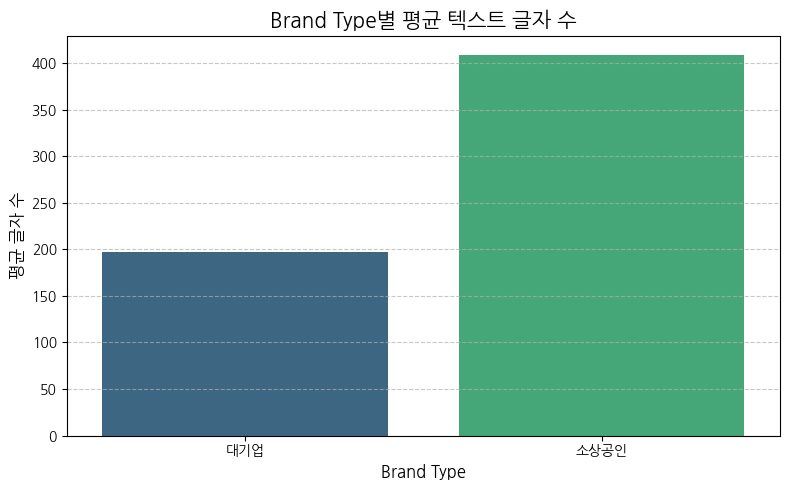

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# brand_type별 평균 글자 수 계산 (이전에 수행된 결과를 재사용)
avg_text_length_by_brand = df_with_brand.groupby('brand_type')['text_length'].mean().reset_index()

# 막대 그래프 시각화
fig = plt.figure(figsize=(8, 5))
sns.barplot(x='brand_type', y='text_length', data=avg_text_length_by_brand, palette='viridis')

plt.title('Brand Type별 평균 텍스트 글자 수', fontsize=15)
plt.xlabel('Brand Type', fontsize=12)
plt.ylabel('평균 글자 수', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('brand_type별_평균글자수_막대그래프.png')
plt.savefig('본문 텍스트 글자 수 평균.png')

plt.show()


In [23]:
# 1. DB에서 브랜드명, brand_type, text_contents를 함께 가져오기
try:
    with conn.cursor() as cursor:
        sql_query_brand_detail = "SELECT text_contents, brand_type, brand_name FROM raw_data_table;"
        cursor.execute(sql_query_brand_detail)
        all_data_brand_detail = cursor.fetchall()

        # 새로운 DataFrame 생성
        df_brand_detail = pd.DataFrame(all_data_brand_detail, columns=['text_contents', 'brand_type', 'brand_name'])
        print(f"총 {len(df_brand_detail)}개의 데이터를 성공적으로 가져왔습니다.")
except Exception as e:
    print(f"오류 발생: {e}")

# 2. 글자 수 계산
df_brand_detail['text_length'] = df_brand_detail['text_contents'].apply(
    lambda x: len(str(x)) if x is not None else 0
)

총 8763개의 데이터를 성공적으로 가져왔습니다.


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 브랜드별 평균 글자 수 계산
avg_by_brand_all = df_brand_detail.groupby(['brand_name', 'brand_type'])['text_length'].mean().reset_index()

# 대기업 / 소상공인 데이터 분리 및 정렬
df_major = avg_by_brand_all[avg_by_brand_all['brand_type'] == '대기업'].sort_values(by='text_length', ascending=False)
df_small = avg_by_brand_all[avg_by_brand_all['brand_type'] == '소상공인'].sort_values(by='text_length', ascending=False)

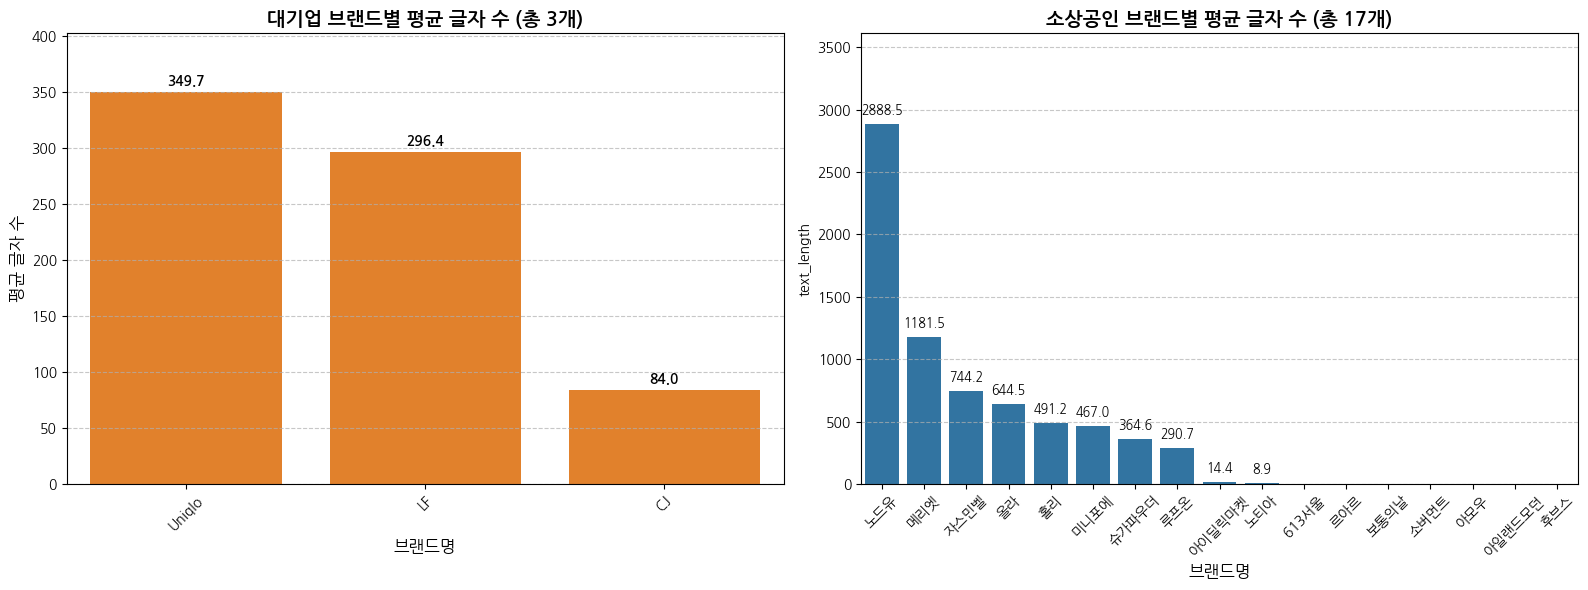

In [31]:
# 2. 1행 2열 구조의 서브플롯 생성
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# [좌측] 대기업 차트
sns.barplot(
    data=df_major,
    x='brand_name',
    y='text_length',
    ax=axes[0],
    color='#ff7f0e'  # 주황색 계열
)
axes[0].set_title(f'대기업 브랜드별 평균 글자 수 (총 {len(df_major)}개)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('브랜드명', fontsize=12)
axes[0].set_ylabel('평균 글자 수', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 대기업 막대 위 수치 표시
for p in axes[0].patches:
    height = p.get_height()
    if height > 0:
        axes[0].annotate(f'{height:.1f}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=10, fontweight='bold', xytext=(0, 3),
                         textcoords='offset points')

# [우측] 소상공인 차트
sns.barplot(
    data=df_small,
    x='brand_name',
    y='text_length',
    ax=axes[1],
    color='#1f77b4'  # 파란색 계열
)
axes[1].set_title(f'소상공인 브랜드별 평균 글자 수 (총 {len(df_small)}개)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('브랜드명', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 소상공인 막대 위 수치 표시 (작은 값도 숫자로 명확히 보임)
for p in axes[1].patches:
    height = p.get_height()
    # 글자 수가 0보다 큰 경우 막대 위에 수치 텍스트 작성 (90도 회전하여 겹침 방지)
    if height > 0:
        axes[1].annotate(f'{height:.1f}',
                         (p.get_x() + p.get_width() / 2., height),
                         ha='center', va='bottom', fontsize=9, rotation=0, xytext=(0, 5),
                         textcoords='offset points')

# 여백 조절 (상단 수치가 잘리지 않도록 y축 범위 15% 여유)
axes[0].set_ylim(0, df_major['text_length'].max() * 1.15)
axes[1].set_ylim(0, df_small['text_length'].max() * 1.25)

plt.tight_layout()

# plt.savefig('브랜드별_텍스트_비교.png')
plt.show()